# Checkpoint Three: Cleaning Data

Now you are ready to clean your data. Before starting coding, provide the link to your dataset below.

My dataset: https://www.kaggle.com/datasets/neharoychoudhury/credit-card-fraud-data/data

Import the necessary libraries and create your dataframe(s).

In [2]:
#Importing the libraries I would need 
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt

#Creating the datagrame
cc_df = pd.read_csv("fraud_data.csv")

In [3]:
cc_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14446 entries, 0 to 14445
Data columns (total 15 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   trans_date_trans_time  14446 non-null  object 
 1   merchant               14446 non-null  object 
 2   category               14446 non-null  object 
 3   amt                    14446 non-null  float64
 4   city                   14446 non-null  object 
 5   state                  14446 non-null  object 
 6   lat                    14446 non-null  float64
 7   long                   14446 non-null  float64
 8   city_pop               14446 non-null  int64  
 9   job                    14446 non-null  object 
 10  dob                    14446 non-null  object 
 11  trans_num              14446 non-null  object 
 12  merch_lat              14446 non-null  float64
 13  merch_long             14446 non-null  float64
 14  is_fraud               14446 non-null  object 
dtypes:

## Missing Data

Test your dataset for missing data and handle it as needed. Make notes in the form of code comments as to your thought process.

In [ ]:
cc_df.isna().sum()

#We have no missing values in the dataframe

trans_date_trans_time    0
merchant                 0
category                 0
amt                      0
city                     0
state                    0
lat                      0
long                     0
city_pop                 0
job                      0
dob                      0
trans_num                0
merch_lat                0
merch_long               0
is_fraud                 0
dtype: int64

## Irregular Data

Detect outliers in your dataset and handle them as needed. Use code comments to make notes about your thought process.

In [ ]:
#Use some descriptive statistics to help identify for outliers.
cc_df.describe()

#The variables below do not seem to contain outliers. The values min and max values make sense for each column 


,amt,lat,long,city_pop,merch_lat,merch_long
count,14446.000000,14446.000000,14446.000000,1.444600e+04,14446.000000,14446.000000
mean,124.430073,39.787692,-110.874225,1.065370e+05,39.787991,-110.874892
std,231.352587,5.317039,12.985813,2.902916e+05,5.360593,12.995596
min,1.000000,20.027100,-165.672300,4.600000e+01,19.032689,-166.670685
25%,12.080000,36.715400,-120.415800,4.930000e+02,36.794655,-120.146253
50%,51.520000,39.666200,-111.098500,1.645000e+03,39.620953,-111.192629
75%,101.030000,41.940400,-101.136000,3.543900e+04,42.275740,-100.446822
max,3261.470000,66.693300,-89.628700,2.383912e+06,67.510267,-88.646366


<Axes: xlabel='lat', ylabel='long'>

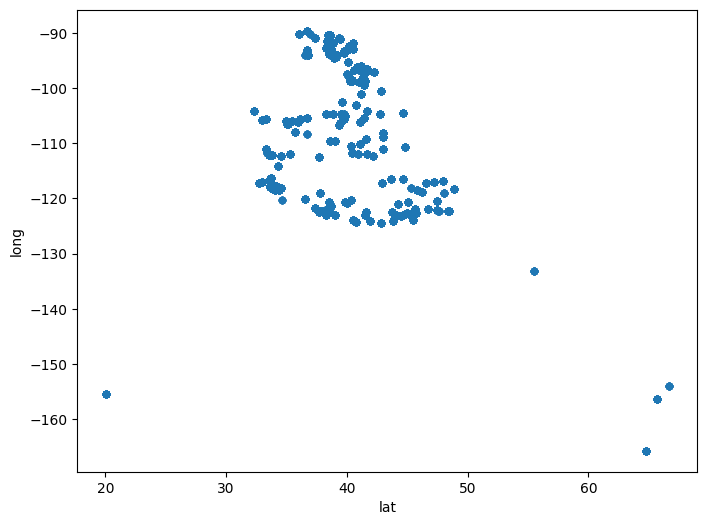

In [ ]:
#Trying to identify outliers with scatterplot for latitud and longitud 
cc_df.plot(kind="scatter", x="lat", y="long", figsize=(8,6))

#I see couple of dots that are far away from the rest, they could mean outliers, maybe a data entry error, or maybe a place that is far away from the rest
#I'm not sure this will affect the analysis I would like to do, so I'm going to leave it as it is

<Axes: xlabel='amt', ylabel='city_pop'>

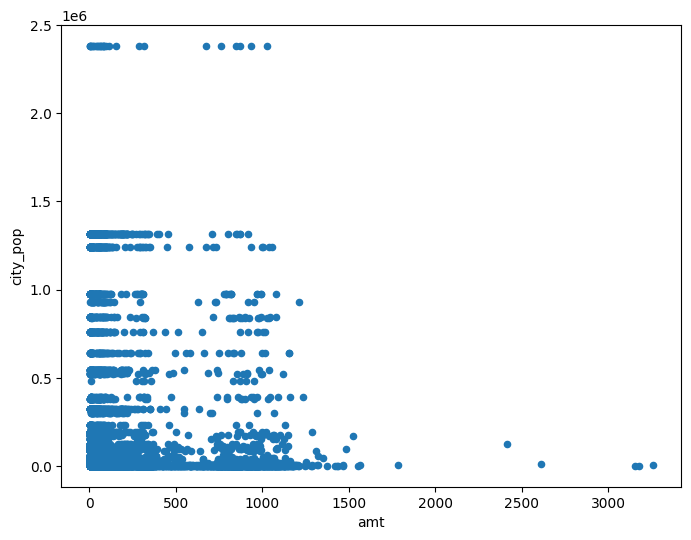

In [6]:
#exploring outliers between amount of transactions and population. I think the expected relationship would be that on average smaller citites 
# would have transactions with less variation of the data, data would be closer vs larger cities where data would be more spread and with more variability
cc_df.plot(kind="scatter", x="amt", y="city_pop", figsize=(8,6))

The points on the far right, where the population is small seem like outliers. Those are high transaction amounts in places with small population.
I believe this could be an indicator of data errors or fraud transactions. I don't think there are too many, so I would keep them from now

In [ ]:
#Identifying some of those values to see if the transaction was consider fraudulent or not

outlier = np.where((cc_df['amt'] > 2000) & 
                       (cc_df['city_pop'] < 10000))

cc_df.iloc[outlier]



,trans_date_trans_time,merchant,category,amt,city,state,lat,long,city_pop,job,dob,trans_num,merch_lat,merch_long,is_fraud
3763,27-12-2020 12:32,Mohr-Baye,shopping_net,3154.76,Red River,NM,36.6659,-105.4694,606,"""Surveyor, land/geomatics""",06-09-1988,3513190d3803bb60a78ac4772591e43f,36.956953,-106.250277,0
5148,28-12-2020 18:44,Turner LLC,travel,3261.47,Mound City,MO,40.1362,-95.2138,1631,Architect,20-01-1953,b5ea3972079963499adf291e2695f317,40.506225,-95.666991,0
8140,01-01-2019 18:51,Boyer-Haley,travel,3178.51,Wales,AK,64.7556,-165.6723,145,"""Administrator, education""",09-11-1939,7083124580d6a391d678fb76b67a1ebb,64.396477,-165.209648,0
10451,08-01-2019 22:41,Kris-Padberg,shopping_pos,2612.14,Moriarty,NM,34.9889,-106.0609,7268,"""Therapist, art""",04-08-1988,607e88409ccdd30e72ad48f2b8695843,35.409797,-106.224560,0


For the outliers that the code identify, the transactions are not considered a fraud. It could be that someone from that small town actually made that transaction, or it could be a data entry error. I'm not going to get rid of them for now. 

## Unnecessary Data

Look for the different types of unnecessary data in your dataset and address it as needed. Make sure to use code comments to illustrate your thought process.

In [ ]:
#I'm checking the column because it seems that it only contains a unique transaction ID number
cc_df["trans_num"].value_counts()

trans_num
a3806e984cec6ac0096d8184c64ad3a1    2
a59185fe1b9ccf21323f581d7477573f    2
86ba3a888b42cd3925881fa34177b4e0    2
3a068fe1d856f0ecedbed33e4b5f4496    2
891cdd1191028759dc20dc224347a0ff    2
                                   ..
699a4c06b22711bf3e0d8ef91232d356    1
080d620d24815c7d6c637cf0b71dde8e    1
3c346c8cd627c5fe3ed57430db2e9ae7    1
e66ffcc95ba7fc490486242af1205d04    1
65e7370f473f9b9d75796c8033a7c929    1
Name: count, Length: 14383, dtype: int64

In [3]:
#I don't think that this data will be necessary for the analysis process so I can get rid of the column so I have a cleaner dataframe
cc_df = cc_df.drop(columns=["trans_num"])

In [ ]:
#Making sure the column was correctly removed
cc_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14446 entries, 0 to 14445
Data columns (total 14 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   trans_date_trans_time  14446 non-null  object 
 1   merchant               14446 non-null  object 
 2   category               14446 non-null  object 
 3   amt                    14446 non-null  float64
 4   city                   14446 non-null  object 
 5   state                  14446 non-null  object 
 6   lat                    14446 non-null  float64
 7   long                   14446 non-null  float64
 8   city_pop               14446 non-null  int64  
 9   job                    14446 non-null  object 
 10  dob                    14446 non-null  object 
 11  merch_lat              14446 non-null  float64
 12  merch_long             14446 non-null  float64
 13  is_fraud               14446 non-null  object 
dtypes: float64(5), int64(1), object(8)
memory usage: 1.5+ 

## Inconsistent Data

Check for inconsistent data and address any that arises. As always, use code comments to illustrate your thought process.

In [3]:
#We I run this code during the EDA process, I noticed there are two incorrect data entries that I need to clean
cc_df["is_fraud"].value_counts()

is_fraud
0                         12600
1                          1844
1"2020-12-24 16:56:24"        1
0"2019-01-01 00:00:44"        1
Name: count, dtype: int64

In [5]:
#I'm going to convert the values in the column to a string so it only takes the first character of each sting and that would clean the values
cc_df["is_fraud"] = cc_df["is_fraud"].astype(str).str[0]
#Now I'm converting the strings into integers to make it easier for the analysis process
cc_df["is_fraud"] = cc_df["is_fraud"].astype(int)

In [ ]:
#Making sure data in the column is clean now
cc_df["is_fraud"].value_counts()

is_fraud
0    12601
1     1845
Name: count, dtype: int64

**Extra cleaning**

In [7]:
#I Want to add a column with the age, which would be easier for data analysis instead of just having DOB
cc_df["dob"] = pd.to_datetime(cc_df["dob"], dayfirst=True)
today = pd.Timestamp.today()
cc_df["age"] = (today - cc_df["dob"]).dt.days // 365


In [12]:
#Converting trans_date_trans_time into a proper datetime column to make better analysis
cc_df["trans_date_trans_time"] = pd.to_datetime(cc_df["trans_date_trans_time"],dayfirst=True)

In [13]:
#Adding an hour column
cc_df["hour"] = cc_df["trans_date_trans_time"].dt.hour

In [14]:
#Adding a day of the week column 
cc_df["day_of_week"] = cc_df["trans_date_trans_time"].dt.day_name()

In [15]:
#Adding a month column
cc_df["month"] = cc_df["trans_date_trans_time"].dt.month

## Summarize Your Results

Make note of your answers to the following questions.

1. Did you find all four types of dirty data in your dataset?

All but missing data. I did not have any null values. 

2. Did the process of cleaning your data give you new insights into your dataset?

It helped me to reshape the data in a way that will make data anaysis easier

3. Is there anything you would like to make note of when it comes to manipulating the data and making visualizations?

Not for now